# IDRiD — **Deep Clustering** → Binary DR Classifier (No DR=0, DR≥1=1)

**Generated:** 2025-08-21

This notebook implements an **iterative Deep Clustering** pretext stage:
1) Start with ImageNet EfficientNet-B0.
2) **Iteratively**: extract features → **k-means** (C clusters) → train network to predict cluster ids (balanced sampling).
3) Transfer the learned backbone → **binary fine-tuning** (No DR vs DR).

**Extras**: circular fundus crop, optional CLAHE, stratified 70/15/15 split, HPO for fine-tuning, confusion matrix, ROC/PR.

**Data paths**:
- CSV: `/kaggle/input/idrid-dataset/idrid_labels.csv`
- Images: `/kaggle/input/idrid-dataset/Imagenes/Imagenes/{id_code}.jpg`


## 1) Setup & Config

In [3]:

import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
seed_everything()

# ==== Preprocessing toggles ====
ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

# ==== Deep Clustering config ====
PRETEXT_CLUSTERS = 10          # number of clusters for deep clustering (try 10~50)
DC_EPOCHS_PER_CYCLE = 2        # train epochs per clustering cycle
DC_CYCLES = 5                  # number of (cluster -> train) cycles
DC_BATCH_SIZE = 64             # larger batch helps

# Feature extraction stability
PCA_DIM = 128                  # PCA dim for clustering stability (set None to disable)
L2_NORMALIZE = True

# ==== Fine-tuning HPO ====
SWEEP_LR = [1e-4, 3e-4]
SWEEP_WD = [1e-5, 1e-4]
SWEEP_DROPOUT = [0.2, 0.4]
SWEEP_EPOCHS = 6
FINAL_EPOCHS = 15
FT_BATCH_SIZE = 32


Device: cpu


## 2) Load CSV, Map to Binary (No DR=0, DR≥1=1) & Image Paths

In [4]:

CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

# Robust read
try:
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
except Exception:
    df = pd.read_csv(CSV_PATH, usecols=[0,1])
    df.columns = ["id_code", "diagnosis"]

df = df[[c for c in df.columns if c.lower() in ("id_code","diagnosis")]].copy()
df.columns = ["id_code","diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = (df["diagnosis"]>0).astype(int)

from pathlib import Path
def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg",".JPG",".png",".jpeg",".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists(): return str(p)
    return str(base.with_suffix(".jpg"))

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nBinary distribution:\n", df["label"].value_counts().sort_index())


     id_code  diagnosis  label  \
0  IDRiD_001          3      1   
1  IDRiD_002          3      1   
2  IDRiD_003          2      1   
3  IDRiD_004          3      1   
4  IDRiD_005          4      1   

                                          image_path  
0  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
1  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
2  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
3  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
4  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  

Binary distribution:
 label
0    129
1    326
Name: count, dtype: int64


## 3) Stratified 70/15/15 Split (on Binary Label)

In [5]:

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name}: {len(d)} |", d["label"].value_counts().sort_index().to_dict())


train: 318 | {0: 90, 1: 228}
val: 68 | {0: 19, 1: 49}
test: 69 | {0: 20, 1: 49}


## 4) Advanced Preprocessing — Circular Crop & CLAHE

In [6]:

import numpy as np

def center_square_crop(np_img):
    h,w = np_img.shape[:2]; s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h,w = sq.shape[:2]
    r = int(0.5*min(h,w)*(1.0-margin)); cy,cx = h//2,w//2
    Y,X = np.ogrid[:h,:w]
    mask = (X-cx)**2 + (Y-cy)**2 <= r*r
    out = np.zeros_like(sq); out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid),int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min())/max(1e-6, g.max()-g.min())
        np_img2 = np_img.copy()
        np_img2[:,:,1] = (g*255.0).astype(np.uint8)
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ, self.clahe, self.clip, self.grid = circ, clahe, clip, grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:  np_img = circular_crop(np_img, margin=0.02)
        if self.clahe: np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)


## 5) Dataset, Transforms & Loaders

In [7]:

train_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224, scale=(0.85,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class IDRiDDataset(Dataset):
    def __init__(self, df, transform, preproc=None, use_binary=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform; self.preproc = preproc
        self.use_binary = use_binary
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None: img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"]) if self.use_binary else int(row["diagnosis"])
        return img, label, row["id_code"]

train_ds = IDRiDDataset(train_df, train_tfms, preproc=preproc, use_binary=True)
val_ds   = IDRiDDataset(val_df,   eval_tfms, preproc=preproc, use_binary=True)
test_ds  = IDRiDDataset(test_df,  eval_tfms, preproc=preproc, use_binary=True)

# A *feature* dataset with eval transforms for stable embeddings
train_feat_ds = IDRiDDataset(train_df, eval_tfms, preproc=preproc, use_binary=True)

def make_loader(ds, batch_size, shuffle, weighted=False):
    if not weighted:
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)
    labels = [lab for _,lab,_ in ds]
    counts = np.bincount(labels, minlength=2)
    weights = 1.0/(counts + 1e-6)
    sample_w = [weights[lab] for lab in labels]
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)

train_loader = make_loader(train_ds, FT_BATCH_SIZE, shuffle=True, weighted=True)
val_loader   = make_loader(val_ds,   FT_BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_ds,  FT_BATCH_SIZE, shuffle=False)
train_feat_loader = DataLoader(train_feat_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


## 6) EfficientNet-B0 Model Helpers

In [8]:

try:
    from torchvision.models import EfficientNet_B0_Weights
    base_weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    base_model = models.efficientnet_b0(weights=base_weights)
except Exception:
    base_model = models.efficientnet_b0(pretrained=True)

def make_headed_model(backbone, out_dim, dropout=0.2):
    m = copy.deepcopy(backbone)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout, inplace=True), nn.Linear(in_features, out_dim))
    return m.to(device)

def extract_features_from_model(trainable_model, dloader, pca_dim=None, l2_norm=True):
    # copy weights and strip classifier for clean 1280-D features
    feat_model = copy.deepcopy(trainable_model).to(device)
    feat_model.classifier = nn.Identity()
    feat_model.eval()
    feats = []
    with torch.no_grad():
        for x,_,_ in dloader:
            x = x.to(device)
            f = feat_model(x)
            feats.append(f.cpu().numpy())
    feats = np.concatenate(feats)
    if l2_norm:
        n = np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8
        feats = feats / n
    if pca_dim is not None:
        pca = PCA(n_components=min(pca_dim, feats.shape[1]))
        scaler = StandardScaler()
        feats = pca.fit_transform(scaler.fit_transform(feats))
    return feats

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x,y,_ in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*x.size(0)
        correct += (logits.argmax(1)==y).sum().item()
        n += x.size(0)
    return total_loss/n, correct/n

@torch.no_grad()
def eval_metrics(model, loader):
    model.eval()
    all_logits, all_y = [], []
    for x,y,_ in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu()); all_y.append(y)
    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy()
    preds = logits.argmax(1)
    acc = accuracy_score(y, preds)
    return acc, preds, y, logits


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


## 7) Deep Clustering — Iterative (features → k-means → train on cluster ids)


=== Deep Clustering cycle 1/5 ===
Unique clusters: 10
[cycle 1] ep 1/2 | loss=2.2019 acc=0.1981
[cycle 1] ep 2/2 | loss=1.9103 acc=0.5189

=== Deep Clustering cycle 2/5 ===
Unique clusters: 10
[cycle 2] ep 1/2 | loss=2.3927 acc=0.0472
[cycle 2] ep 2/2 | loss=2.0284 acc=0.1667

=== Deep Clustering cycle 3/5 ===
Unique clusters: 10
[cycle 3] ep 1/2 | loss=2.6806 acc=0.0755
[cycle 3] ep 2/2 | loss=2.1158 acc=0.2044

=== Deep Clustering cycle 4/5 ===
Unique clusters: 10
[cycle 4] ep 1/2 | loss=2.2635 acc=0.1604
[cycle 4] ep 2/2 | loss=1.9189 acc=0.2830

=== Deep Clustering cycle 5/5 ===
Unique clusters: 10
[cycle 5] ep 1/2 | loss=2.7283 acc=0.0440
[cycle 5] ep 2/2 | loss=2.1937 acc=0.1667


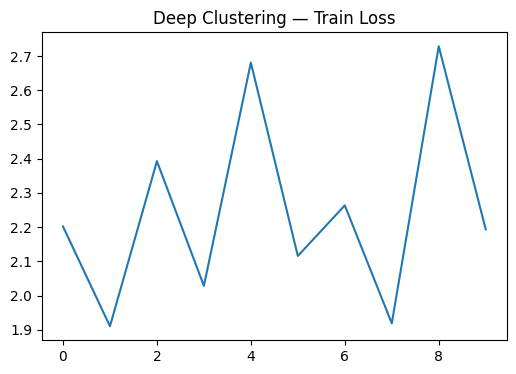

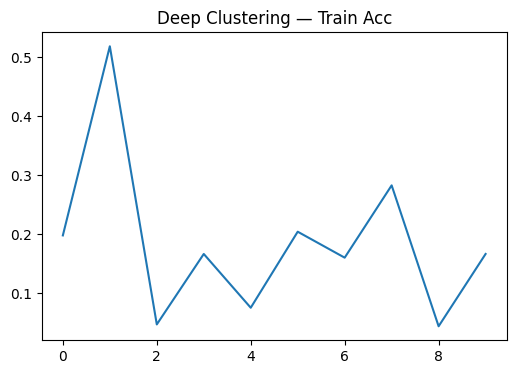

In [9]:

C = PRETEXT_CLUSTERS
dc_model = make_headed_model(base_model, out_dim=C, dropout=0.2)
optimizer_dc = torch.optim.AdamW(dc_model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion_dc = nn.CrossEntropyLoss()

history_dc = {"cycle":[], "train_loss":[], "train_acc":[], "unique_clusters":[]}

for cycle in range(1, DC_CYCLES+1):
    print(f"\n=== Deep Clustering cycle {cycle}/{DC_CYCLES} ===")
    # 1) extract features on train (no aug) with current model weights
    feats = extract_features_from_model(dc_model, train_feat_loader, pca_dim=PCA_DIM, l2_norm=L2_NORMALIZE)
    # 2) k-means
    ok = False
    for attempt in range(5):
        km = KMeans(n_clusters=C, n_init=10, random_state=SEED+cycle+attempt)
        cluster_ids = km.fit_predict(feats)
        uniq = np.unique(cluster_ids)
        if len(uniq) >= max(2, C//2):  # avoid collapse
            ok = True; break
    if not ok:
        print("Warning: k-means collapse, reducing clusters to", len(uniq))
        C = len(uniq)
        dc_model = make_headed_model(base_model, out_dim=C, dropout=0.2)  # reinit head
        optimizer_dc = torch.optim.AdamW(dc_model.parameters(), lr=3e-4, weight_decay=1e-4)
        criterion_dc = nn.CrossEntropyLoss()

    print("Unique clusters:", len(np.unique(cluster_ids)))
    # 3) build pseudo-label dataset with BALANCED sampling across clusters
    counts = np.bincount(cluster_ids, minlength=C)
    weights = 1.0/(counts + 1e-6)

    class PseudoClusterDS(Dataset):
        def __init__(self, base_ds, pseudo_y):
            self.base_ds = base_ds; self.pseudo_y = pseudo_y
        def __len__(self): return len(self.base_ds)
        def __getitem__(self, idx):
            x,_,idc = self.base_ds[idx]
            return x, int(self.pseudo_y[idx]), idc

    pseudo_ds = PseudoClusterDS(train_ds, cluster_ids)
    sample_w = [weights[c] for c in cluster_ids]
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    pseudo_loader = DataLoader(pseudo_ds, batch_size=DC_BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

    # 4) train a few epochs to predict clusters
    for ep in range(1, DC_EPOCHS_PER_CYCLE+1):
        tr_loss, tr_acc = train_epoch(dc_model, pseudo_loader, optimizer_dc, criterion_dc)
        print(f"[cycle {cycle}] ep {ep}/{DC_EPOCHS_PER_CYCLE} | loss={tr_loss:.4f} acc={tr_acc:.4f}")
        history_dc["cycle"].append(cycle); history_dc["train_loss"].append(tr_loss)
        history_dc["train_acc"].append(tr_acc); history_dc["unique_clusters"].append(int(len(np.unique(cluster_ids))))

# Plot pretext trends
plt.figure(figsize=(6,4)); plt.plot(history_dc["train_loss"]); plt.title("Deep Clustering — Train Loss"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(history_dc["train_acc"]);  plt.title("Deep Clustering — Train Acc");  plt.show()


## 8) Supervised Binary Fine-Tuning (HPO → Final)


=== HPO: lr=0.0001, wd=1e-05, dropout=0.2 ===
Val F1=0.8471 Acc=0.8088

=== HPO: lr=0.0001, wd=1e-05, dropout=0.4 ===
Val F1=0.7436 Acc=0.7059

=== HPO: lr=0.0001, wd=0.0001, dropout=0.2 ===
Val F1=0.8333 Acc=0.7941

=== HPO: lr=0.0001, wd=0.0001, dropout=0.4 ===
Val F1=0.7901 Acc=0.7500

=== HPO: lr=0.0003, wd=1e-05, dropout=0.2 ===
Val F1=0.8889 Acc=0.8529

=== HPO: lr=0.0003, wd=1e-05, dropout=0.4 ===
Val F1=0.9684 Acc=0.9559

=== HPO: lr=0.0003, wd=0.0001, dropout=0.2 ===
Val F1=0.9348 Acc=0.9118

=== HPO: lr=0.0003, wd=0.0001, dropout=0.4 ===
Val F1=0.9574 Acc=0.9412


,lr,wd,dropout,val_acc,val_f1
0,0.0003,0.00001,0.4,0.955882,0.968421
1,0.0003,0.00010,0.4,0.941176,0.957447
2,0.0003,0.00010,0.2,0.911765,0.934783
3,0.0003,0.00001,0.2,0.852941,0.888889
4,0.0001,0.00001,0.2,0.808824,0.847059
5,0.0001,0.00010,0.2,0.794118,0.833333
6,0.0001,0.00010,0.4,0.750000,0.790123
7,0.0001,0.00001,0.4,0.705882,0.743590


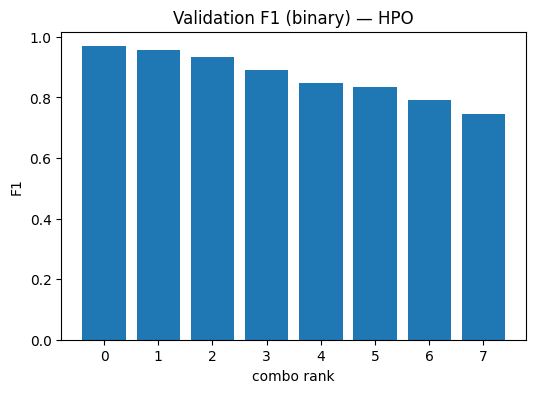

Best HP: {'lr': 0.0003, 'wd': 1e-05, 'dropout': 0.4} Best F1: 0.968421052631579
[Final] ep 1/15 | loss=0.4288 | val_f1=0.5797 (acc=0.5735)
[Final] ep 2/15 | loss=0.2239 | val_f1=0.9231 (acc=0.8971)
[Final] ep 3/15 | loss=0.1756 | val_f1=0.9348 (acc=0.9118)
[Final] ep 4/15 | loss=0.1073 | val_f1=0.9348 (acc=0.9118)
[Final] ep 5/15 | loss=0.1075 | val_f1=0.9684 (acc=0.9559)
[Final] ep 6/15 | loss=0.0898 | val_f1=0.9348 (acc=0.9118)
[Final] ep 7/15 | loss=0.0514 | val_f1=0.9462 (acc=0.9265)
[Final] ep 8/15 | loss=0.0890 | val_f1=0.9495 (acc=0.9265)
[Final] ep 9/15 | loss=0.0626 | val_f1=0.9474 (acc=0.9265)
[Final] ep 10/15 | loss=0.0568 | val_f1=0.9263 (acc=0.8971)
[Final] ep 11/15 | loss=0.0604 | val_f1=0.9600 (acc=0.9412)
[Final] ep 12/15 | loss=0.0639 | val_f1=0.9495 (acc=0.9265)
[Final] ep 13/15 | loss=0.0501 | val_f1=0.9485 (acc=0.9265)
[Final] ep 14/15 | loss=0.0730 | val_f1=0.9375 (acc=0.9118)
[Final] ep 15/15 | loss=0.0322 | val_f1=0.9485 (acc=0.9265)


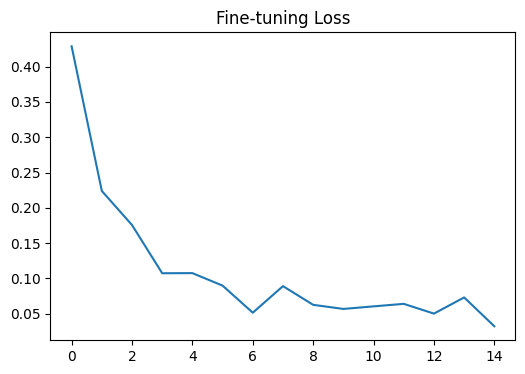

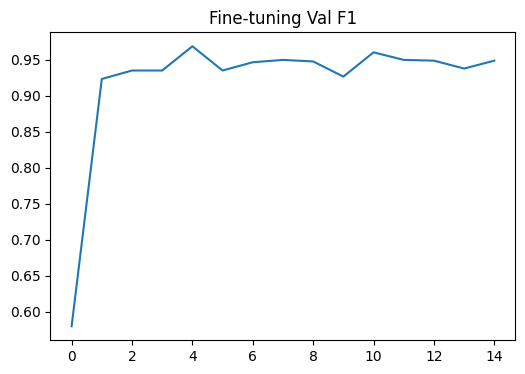

In [10]:

NUM_CLASSES = 2

def make_finetune_model(from_model, num_out, dropout_p):
    # copy weights, replace head
    m = copy.deepcopy(from_model)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout_p, inplace=True), nn.Linear(in_features, num_out))
    return m.to(device)

# class imbalance weights
counts = train_df["label"].value_counts().sort_index().values
class_weights = torch.tensor(1.0/(counts + 1e-6), dtype=torch.float32).to(device)

# HPO
results = []
best = {"f1": -1, "hp": None, "state": None}
for lr in SWEEP_LR:
    for wd in SWEEP_WD:
        for dp in SWEEP_DROPOUT:
            print(f"\n=== HPO: lr={lr}, wd={wd}, dropout={dp} ===")
            model = make_finetune_model(dc_model, NUM_CLASSES, dropout_p=dp)
            crit = nn.CrossEntropyLoss(weight=class_weights)
            opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SWEEP_EPOCHS)

            # train for SWEEP_EPOCHS
            for ep in range(1, SWEEP_EPOCHS+1):
                loss, acc = train_epoch(model, train_loader, opt, crit)
                sch.step()

            # val
            v_acc, _, v_y, v_logits = eval_metrics(model, val_loader)
            v_pred = v_logits.argmax(1)
            v_f1 = f1_score(v_y, v_pred, average="binary")
            results.append({"lr":lr,"wd":wd,"dropout":dp,"val_acc":v_acc,"val_f1":v_f1})
            print(f"Val F1={v_f1:.4f} Acc={v_acc:.4f}")
            if v_f1 > best["f1"]:
                best["f1"] = v_f1
                best["hp"] = {"lr":lr,"wd":wd,"dropout":dp}
                best["state"] = copy.deepcopy(model.state_dict())

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df)

plt.figure(figsize=(6,4)); plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("Validation F1 (binary) — HPO"); plt.xlabel("combo rank"); plt.ylabel("F1"); plt.show()

print("Best HP:", best["hp"], "Best F1:", best["f1"])

# Final training with best HP
hp = best["hp"]
ft_model = make_finetune_model(dc_model, NUM_CLASSES, dropout_p=hp["dropout"])
crit = nn.CrossEntropyLoss(weight=class_weights)
opt = torch.optim.AdamW(ft_model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINAL_EPOCHS)

hist = {"train_loss":[], "val_f1":[]}
best_val_f1, best_state = -1, None

for ep in range(1, FINAL_EPOCHS+1):
    tr_loss, tr_acc = train_epoch(ft_model, train_loader, opt, crit)
    sch.step()
    v_acc, _, v_y, v_logits = eval_metrics(ft_model, val_loader)
    v_pred = v_logits.argmax(1)
    v_f1 = f1_score(v_y, v_pred, average="binary")
    hist["train_loss"].append(tr_loss); hist["val_f1"].append(v_f1)
    print(f"[Final] ep {ep}/{FINAL_EPOCHS} | loss={tr_loss:.4f} | val_f1={v_f1:.4f} (acc={v_acc:.4f})")
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1; best_state = copy.deepcopy(ft_model.state_dict())

ft_model.load_state_dict(best_state)

plt.figure(figsize=(6,4)); plt.plot(hist["train_loss"]); plt.title("Fine-tuning Loss"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(hist["val_f1"]);   plt.title("Fine-tuning Val F1"); plt.show()


## 9) Test Evaluation & Plots

Test Accuracy: 0.8841 | Test F1 (binary): 0.9111

Classification Report (Binary, Test):
              precision    recall  f1-score   support

   No DR (0)     0.7143    1.0000    0.8333        20
      DR (1)     1.0000    0.8367    0.9111        49

    accuracy                         0.8841        69
   macro avg     0.8571    0.9184    0.8722        69
weighted avg     0.9172    0.8841    0.8886        69



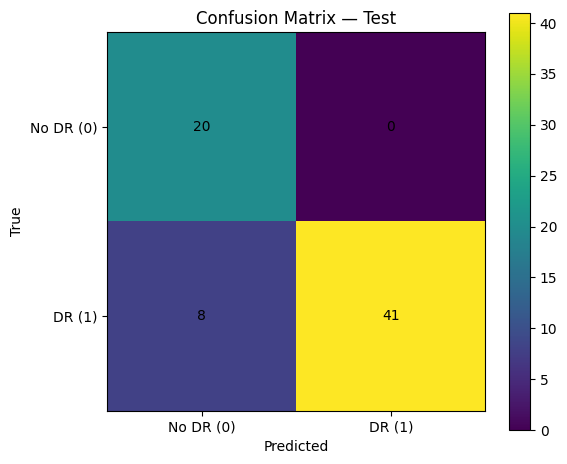

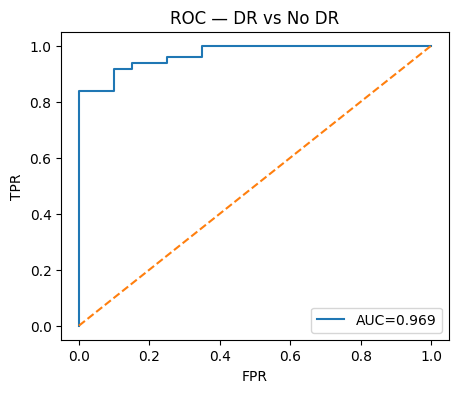

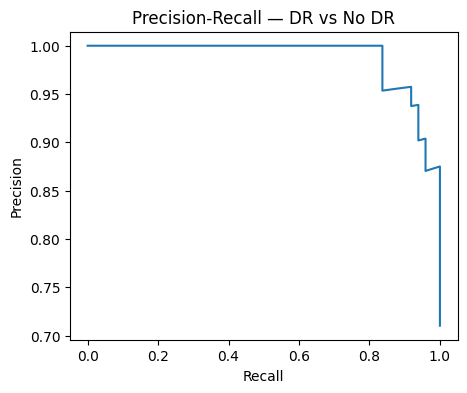

In [11]:

# Test
t_acc, _, t_y, t_logits = eval_metrics(ft_model, test_loader)
t_pred = t_logits.argmax(1)
t_f1 = f1_score(t_y, t_pred, average="binary")
print(f"Test Accuracy: {t_acc:.4f} | Test F1 (binary): {t_f1:.4f}")

# Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report (Binary, Test):")
print(classification_report(t_y, t_pred, target_names=["No DR (0)","DR (1)"], digits=4))

cm = confusion_matrix(t_y, t_pred, labels=[0,1])
plt.figure(figsize=(6,5)); plt.imshow(cm, interpolation='nearest'); plt.title("Confusion Matrix — Test")
plt.colorbar(); plt.xticks([0,1], ["No DR (0)","DR (1)"]); plt.yticks([0,1], ["No DR (0)","DR (1)"])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.tight_layout(); plt.show()

# ROC & PR
probs = torch.softmax(torch.tensor(t_logits), dim=1).numpy()[:,1]
fpr, tpr, _ = roc_curve(t_y, probs)
auc = roc_auc_score(t_y, probs)
plt.figure(figsize=(5,4)); plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],linestyle="--"); plt.title("ROC — DR vs No DR"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(t_y, probs)
plt.figure(figsize=(5,4)); plt.plot(rec,prec)
plt.title("Precision-Recall — DR vs No DR"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.show()


## 10) Save Artifacts

In [12]:

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
torch.save(ft_model.state_dict(), OUT/"best_model_binary_deepclust.pth")

import json as _json
with open(OUT/"best_ft_hparams.json","w") as f:
    _json.dump(dict(best_hp=best["hp"]), f, indent=2)

# test preds
pd.DataFrame({"id_code": test_df["id_code"].values,
              "true": test_df["label"].values,
              "pred": t_pred}).to_csv(OUT/"test_predictions_binary_deepclust.csv", index=False)

print("Saved:", OUT/"best_model_binary_deepclust.pth",
      OUT/"best_ft_hparams.json", OUT/"test_predictions_binary_deepclust.csv")


Saved: outputs/best_model_binary_deepclust.pth outputs/best_ft_hparams.json outputs/test_predictions_binary_deepclust.csv
